<a href="https://colab.research.google.com/github/yiqi0806-collab/global-sensitivity-analysis/blob/main/test_GAS_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import numpy.random as R
from scipy.stats import qmc
from scipy.stats import norm
from scipy.stats import chi2
from scipy import stats
import random
import math
import matplotlib.pyplot as plt
from numpy.linalg import eig
%matplotlib inline

# Calculate the matrix B
def dFunc0(x,Func,M2,shiftedSobol=True,distribution='normal'):    #rememebr to change distribution if not use shiftedSobol
    chi,dim = x.shape[0],x.shape[1]
    temp = np.zeros((dim,chi*M2))
    #print("55555",x)
    if(shiftedSobol == True):
        rand_add = qmc.Sobol(dim, scramble=False).random(M2+1)[1:]
        for i in range(M2):
            xe = np.tile(x.transpose(), dim).transpose()*(1-np.repeat(np.array(np.identity(dim)), chi, axis=0))
            if distribution == 'normal':
                rand = norm.ppf((norm.cdf(x)+rand_add[i])%1)
            elif distribution == 'uniform':
                rand = (x+rand_add[i])%1
            elif distribution =='chi_squared':
                rand1 = chi2.ppf((chi2.cdf(x[:,0],df=10)+rand_add[i][0])%1, df=10)
                rand2 = chi2.ppf((chi2.cdf(x[:,1],df=13.978)+rand_add[i][1])%1, df=13.978)
                rand = np.column_stack((rand1, rand2))
            #print("22222",rand)
            xe += rand.T.reshape(dim*chi,1)*np.repeat(np.array(np.identity(dim)), chi, axis=0)
            #print("11111",xe)
            #xe += rand.T * np.repeat(np.array(np.identity(dim)), chi, axis=0)
            print("55555",x.shape)
            print("66666",Func(xe).shape)
            print("77777",Func(x).shape)
            print("8888",np.tile(Func(x),dim).shape)
            temp[:,i*(chi):(i+1)*(chi)] = ((Func(xe)-np.tile(Func(x),dim))/np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1)).reshape(dim,chi)

    else:
        for i in range(M2):
            xe = np.tile(x.transpose(), dim).transpose()*(1-np.repeat(np.array(np.identity(dim)), chi, axis=0))
            if distribution == 'normal':
                rand = R.normal(0,1,(chi,dim))
            elif distribution == 'uniform':
                rand = R.uniform(0,1,(chi,dim))
            xe += rand.T.reshape(dim*chi,1)*np.repeat(np.array(np.identity(dim)), chi, axis=0)
            temp[:,i*(chi):(i+1)*(chi)] = ((Func(xe)-np.tile(Func(x),dim))/np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1)).reshape(dim,chi)

    return temp

# Calculate eigenvalue decomposition //Func in put is m*n matrix, where n is the dimension of x of f(x), m is how many sample to repeat for x 比如100*10 100个x 每个x是10dimension.
#                     output is m number of result f(x), it's a list.
def GAS(Func,dim,chi,M1,M2,shiftedSobol=True,distribution='normal'):      #remember to change distribution
    if distribution == 'normal':
        z = R.normal(0, 1, (M1, dim))
    elif distribution == 'uniform':
        z = R.uniform(0, 1, (M1, dim))
    elif distribution == 'chi_squared':                 #special case for chi_squared
        x1_samples = R.chisquare(df=10, size=M1)
        x2_samples = R.chisquare(df=13.978, size=M1)
        z = np.column_stack((x1_samples, x2_samples))
    deriv = dFunc0(z,Func,M2,shiftedSobol,distribution=distribution)
    deriv /= np.sqrt(chi)
    u, s, vh = np.linalg.svd(deriv.astype(float), full_matrices=True)
    s = s**2
    return u, s



# Estimate the matrix Phi
def Phi_est(X, expo, coef, P):
    Num = X.shape[0]
    dim = X.shape[1]
    return np.dot(np.prod((np.tile(X, P)**expo.flatten()).reshape((Num*P, dim)),axis = 1).reshape((Num, P))
               ,np.array(coef)).T

def Funy(z,z1,u,Func):
    dim = u.shape[0]
    dim1 = z.shape[1]
    chi = z.shape[0]
    f1 = Func(np.dot(z,u[:,:dim1].transpose())+np.dot(z1,u[:,dim1:].transpose()))
    return f1

# Estimate k hat
def estimate_k_reg1(z,z1,u, exponents, coefficients, P, Func):
    phi = Phi_est(z, exponents, coefficients,P)
    khat = np.linalg.inv(phi @ np.transpose(phi)) @ phi @ Funy(z,z1,u,Func)
    return khat

# Estimate the expectation from PCE
def GAS_PCE(Func, Num_exp, z1, dim1, u, exponents, coefficients, P):
    PCE = np.zeros(Num_exp)
    for i in range(Num_exp):
        kii = estimate_k_reg1(z1[i][:,:dim1], z1[i][:,dim1:], u, exponents, coefficients, P, Func)
        PCE[i] = kii[0]
    return PCE

def GAS_score(m,u,s):                         #m is how many eigenvalue we use
  gas_score = u[:,:m]**2@s[:m]/sum(u[:,:m]**2@s[:m])
  return gas_score

#def Func(x):
#  x1=x[:, 0] + 0.1 * np.sum(np.sin(100 * x[:, 1:]), axis = 1)   #example 1
#  return x1

#def Func(x):                                  #example 2
#  x=x-0.5
#  # Summation of i * x_i for i in range 1 to 10
#  summation = sum(i * x[:,i-1] for i in range(1, 11))

  # Interaction term
#  interaction = 10 * (x[:,0] * x[:,1] - x[:,8] * x[:,9])

  # Noise term from N(0, 1)
#  noise = 1*R.normal(0,1,x.shape[0])
  # Final result
#  return summation + interaction + noise

#def Func(x):                                  #example 3
#  return 0.9*x[:,0]+0.6*x[:,1]+0.1*x[:,2]+0.001*x[:,3]

def Func(x):
    # example 1
    result = np.exp(0.8 * x[:, 0] + 0.6 * x[:, 1]) + 0.001 * x[:, 2]
    return result


55555 (10000, 3)
66666 (30000,)
77777 (10000,)
8888 (30000,)
[[-7.73449715e-01  6.33857571e-01 -3.41869577e-04]
 [-6.33857531e-01 -7.73449790e-01 -2.30260623e-04]
 [-4.10371392e-04  3.86015932e-05  9.99999915e-01]]
[3.55647834e+00 4.46169736e-01 4.00407643e-07]


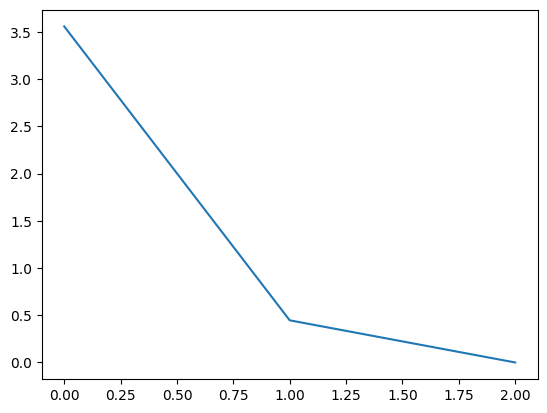

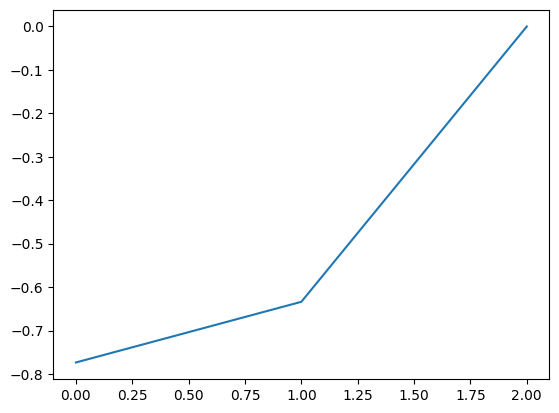

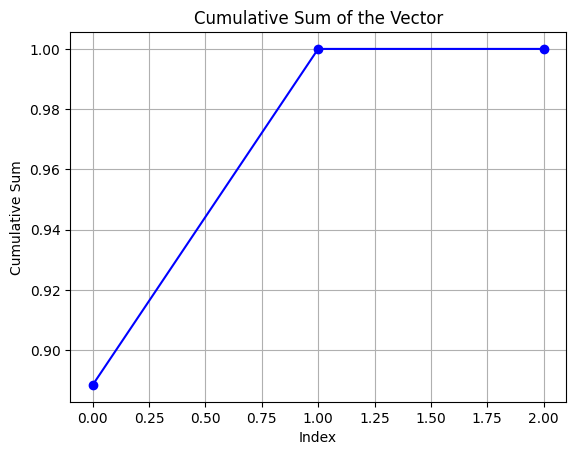

GAS_score is [5.98224462e-01 4.01775369e-01 1.68404679e-07]


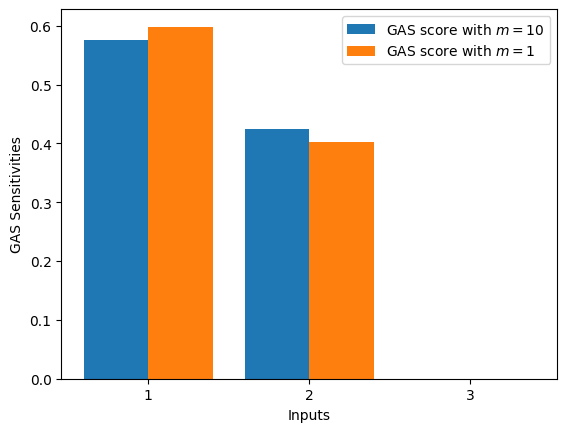

1.0


In [ ]:
dim=3
chi=10000
M1=10000
M2=1


u0, s0 = GAS(Func,dim,chi,M1,M2,shiftedSobol=True)
print(u0)
print(s0)
plt.plot(s0)
plt.show()

plt.plot(u0[:,0])
plt.show()

cumulative_sum = np.cumsum(s0)
cumulative_sum_percentage = (cumulative_sum / cumulative_sum[-1])
# Plot the cumulative sum
plt.plot(cumulative_sum_percentage, marker='o', linestyle='-', color='b')
plt.title("Cumulative Sum of the Vector")
plt.xlabel("Index")
plt.ylabel("Cumulative Sum")
plt.grid(True)
plt.show()


print("GAS_score is",GAS_score(1,u0,s0))

width = 0.4
x = np.arange(1,dim+1)
labels = x
fig, ax4 = plt.subplots()
rects1 = ax4.bar(x-width/2, GAS_score(10,u0,s0), width, label='GAS score with $m = 10$')
rects2 = ax4.bar(x+width/2, GAS_score(1,u0,s0), width, label='GAS score with $m = 1$')
ax4.set_ylabel('GAS Sensitivities')
ax4.set_xlabel('Inputs')
ax4.set_xticks(x)
ax4.set_xticklabels(labels)
# Add a legend
ax4.legend()
# Show the plot
plt.show()

print(sum(GAS_score(10,u0,s0)))

In [ ]:
import numpy as np
!pip install SALib
from SALib.sample import saltelli
from SALib.analyze import sobol
import matplotlib.pyplot as plt

problem = {
    'num_vars': 10,
    'names': [f'x{i+1}' for i in range(10)],
    'bounds': [[0, 1]] * 10  # Uniform distribution for each variable
}

# Generate Saltelli samples
N = 10000  # Base sample size
param_values = saltelli.sample(problem, N, calc_second_order=True)

# Evaluate the function
Y = Func(param_values)

# Perform Sobol sensitivity analysis
Si = sobol.analyze(problem, Y, calc_second_order=True)

# Display Sobol indices
print("Global Sobol Sensitivity Indices:")
for i, param in enumerate(problem['names']):
    print(f"{param}:")
    print(f"  First-Order (S1): {Si['S1'][i]:.4f}")
    print(f"  Total-Effect (ST): {Si['ST'][i]:.4f}")

# Plot First-Order and Total-Effect Sobol Indices
#x = np.arange(len(problem['names']))
#width = 0.35  # Bar width for the plot

#plt.figure(figsize=(12, 6))
#plt.bar(x - width / 2, Si['S1'], width, label='First-Order (S1)', color='lightcoral')
#plt.bar(x + width / 2, Si['ST'], width, label='Total-Effect (ST)', color='skyblue')
#plt.xticks(x, problem['names'])
#plt.xlabel("Parameters")
#plt.ylabel("Sobol Index Value")
#plt.title("Global Sobol Sensitivity Indices for Func(x)")
#plt.legend()
#plt.grid(axis='y')
#plt.show()

width = 0.4
x = np.arange(1,dim+1)
labels = x
fig, ax4 = plt.subplots()
rects1 = ax4.bar(x-width/2, Si['ST'], width, label='Total-Effect (ST)')
rects2 = ax4.bar(x+width/2, Si['S1'], width, label='First-Order (S1)')
ax4.set_ylabel('Sobal Sensitivities')
ax4.set_xlabel('Inputs')
ax4.set_xticks(x)
ax4.set_xticklabels(labels)
# Add a legend
ax4.legend()
# Show the plot
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 778.9/778.9 kB 13.9 MB/s eta 0:00:00


<ipython-input-1-db1fda22b279>:15: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)
/usr/local/lib/python3.11/dist-packages/SALib/sample/saltelli.py:110: UserWarning: 
        Convergence properties of the Sobol' sequence is only valid if
        `N` (10000) is equal to `2^n`.
        
  warnings.warn(msg)


NameError: name 'Func' is not defined

               vi        vi_std          dgsm     dgsm_conf
x1   5.157280e+08  3.627219e+10  1.506393e+06  7.418809e+08
x2   2.030362e+09  1.857303e+11  5.930498e+06  3.240757e+09
x3   8.852802e+08  5.904384e+10  2.585820e+06  1.156207e+09
x4   3.723437e+08  1.929964e+10  1.087581e+06  3.450337e+08
x5   1.257362e+08  4.484427e+09  3.672636e+05  9.001492e+07
x6   4.821073e+08  3.461590e+10  1.408190e+06  6.171626e+08
x7   1.715704e+08  8.612231e+09  5.011410e+05  1.948830e+08
x8   4.450728e+08  2.465619e+10  1.300016e+06  6.089744e+08
x9   1.751402e+08  7.308339e+09  5.115680e+05  1.518007e+08
x10  5.285588e+08  3.683526e+10  1.543871e+06  7.286163e+08


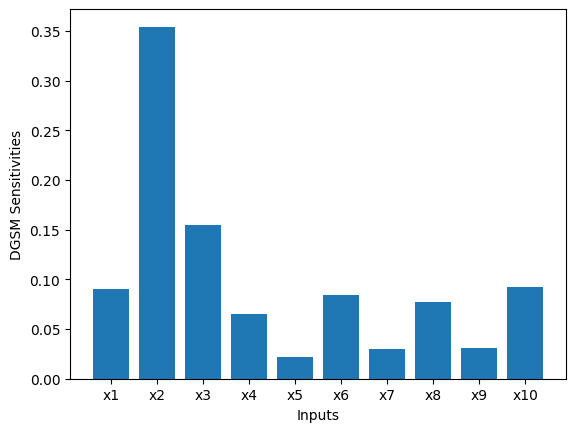

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from SALib.analyze import dgsm
from SALib.sample import finite_diff

problem = {
    'num_vars': 10,
    'names': [f'x{i+1}' for i in range(10)],
    'bounds': [[0, 1]] * 10
}

N = 10000
param_values = finite_diff.sample(problem, N)
Y = Func(param_values)  # Your model output here

# Run DGSM
dgsm_results = dgsm.analyze(problem, param_values, Y, print_to_console=True)

# Normalize
vi = dgsm_results['vi']
vi_normalized = vi / np.sum(vi)

# Plot
fig, ax4 = plt.subplots()
plt.bar(problem['names'], vi_normalized)
ax4.set_ylabel('DGSM Sensitivities')
ax4.set_xlabel('Inputs')
ax4.set_xticks(np.arange(10))
ax4.set_xticklabels(problem['names'])
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 778.9/778.9 kB 9.1 MB/s eta 0:00:00


<ipython-input-1-eb4d77ce297c>:19: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)
/usr/local/lib/python3.11/dist-packages/SALib/sample/saltelli.py:110: UserWarning: 
        Convergence properties of the Sobol' sequence is only valid if
        `N` (1000) is equal to `2^n`.
        
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


          ST   ST_conf
x1  0.592415  0.055891
x2  0.443634  0.042637
          S1   S1_conf
x1  0.554225  0.063948
x2  0.408378  0.049407
                S2   S2_conf
[x1, x2]  0.042336  0.093659


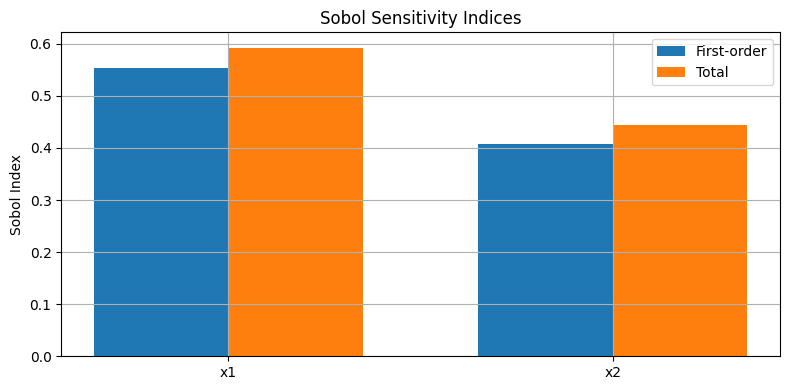

In [ ]:
import numpy as np
!pip install SALib
import time
import SALib
from SALib.sample import saltelli
from SALib.analyze import sobol
import matplotlib.pyplot as plt


# Define the model input
problem = {
    'num_vars': 2,
    'names': ['x1', 'x2'],
    'bounds': [[1, 3], [2, 5]]
}

# Generate samples using Saltelli's method
N = 1000  # Sample size (you can increase for better accuracy)
param_values = saltelli.sample(problem, N, calc_second_order=True)

# Define the model function
def model(X):
    x1 = X[:, 0]
    x2 = X[:, 1]
    return x1 * x2

# Evaluate the model
Y = model(param_values)

# Perform Sobol' sensitivity analysis
Si = sobol.analyze(problem, Y, print_to_console=True)

# Optional: Plot first-order and total-effect indices
labels = problem['names']
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, Si['S1'], width, label='First-order')
plt.bar(x + width/2, Si['ST'], width, label='Total')
plt.xticks(x, labels)
plt.ylabel('Sobol Index')
plt.title('Sobol Sensitivity Indices')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

           vi    vi_std      dgsm  dgsm_conf
x1  13.003958  6.099927  0.717752   0.386654
x2   4.335209  2.329007  0.538383   0.147695


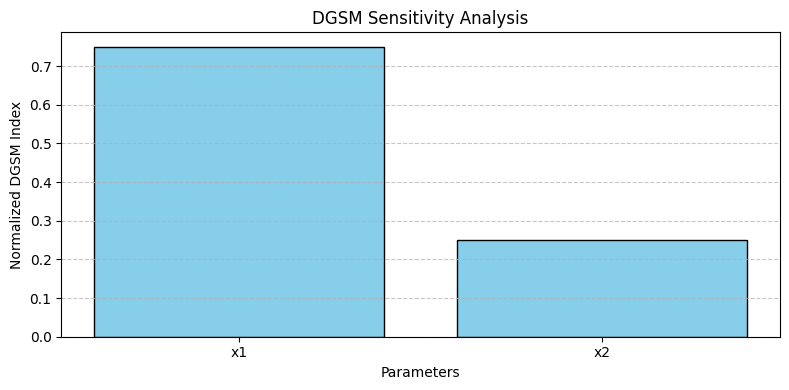

In [ ]:
import numpy as np
!pip install SALib
import SALib
from SALib.sample.morris import sample as morris_sample
from SALib.analyze import dgsm
import matplotlib.pyplot as plt
from SALib.sample import finite_diff

# Define the model input
problem = {
    'num_vars': 2,
    'names': ['x1', 'x2'],
    'bounds': [[1, 3], [2, 5]]
}

# Generate samples for DGSM (Morris sampling is reused for DGSM)
N = 1000  # number of samples
param_values = finite_diff.sample(problem, N)

# Define the model
def model(X):
    # Rescale back to real ranges
    x1 = X[:, 0]
    x2 = X[:, 1]
    return x1 * x2

# Evaluate the model
Y = model(param_values)

# Perform DGSM analysis
dgsm_results = dgsm.analyze(problem, param_values, Y, print_to_console=True)

# Normalize DGSM indices
vi = np.array(dgsm_results['vi'])
vi_normalized = vi / np.sum(vi)

# Plot the normalized DGSM indices
plt.figure(figsize=(8, 4))
plt.bar(problem['names'], vi_normalized, color='skyblue', edgecolor='black')
plt.xlabel('Parameters')
plt.ylabel('Normalized DGSM Index')
plt.title('DGSM Sensitivity Analysis')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
